# Notebook 4 - Full Three-Run Training Campaign

This notebook executes the three main training runs in one controlled campaign:
- **Gaussian**: exact DDPM epsilon-prediction baseline
- **Uniform**: matched-variance direct-corruption surrogate
- **Laplace**: matched-variance direct-corruption surrogate

Design principles of this notebook:
1. one execution launches the full three-run study,
2. the same architecture, optimizer, budget, initialization seed, and data-order seed are reused across runs,
3. each run still keeps separate checkpoints, logs, TensorBoard records, and final sample grids.



In [7]:
!pip install -q torch torchvision tqdm matplotlib numpy tensorboard


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import math, os, csv, time, json
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/diffusion_noise_project'
os.makedirs(PROJECT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    if hasattr(torch.backends.cuda.matmul, 'allow_tf32'):
        torch.backends.cuda.matmul.allow_tf32 = True
    if hasattr(torch.backends.cudnn, 'allow_tf32'):
        torch.backends.cudnn.allow_tf32 = True

print(f'Torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}')
    print(f'Total GPU memory: {props.total_memory / 1024**3:.1f} GB')
print(f'Device: {DEVICE}')

if DEVICE.type != 'cuda':
    raise RuntimeError(
        'This notebook is intended for full GPU training. In Colab, select Runtime > Change runtime type > GPU and rerun.'
    )



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Total GPU memory: 14.6 GB
Device: cuda


## 0. Campaign Definition

The notebook now runs the three main experiments sequentially. No manual parameter switching is required between runs.



In [9]:
NOISE_TYPES = ['gaussian', 'uniform', 'laplace']

RUN_LABELS = {
    'gaussian': 'Gaussian (exact DDPM baseline)',
    'uniform': 'Uniform (matched-variance surrogate)',
    'laplace': 'Laplace (matched-variance surrogate)',
}
TRAINING_OBJECTIVE = {
    'gaussian': 'Exact DDPM epsilon prediction under the standard Gaussian forward law.',
    'uniform': 'Epsilon prediction under a matched-variance direct-corruption surrogate.',
    'laplace': 'Epsilon prediction under a matched-variance direct-corruption surrogate.',
}
SAMPLER_NOTE = (
    'Reverse sampling still uses the standard Gaussian DDPM update. '
    'That update is exact for the Gaussian baseline and should be interpreted with caution for the surrogate runs.'
)

print('Campaign order:')
for noise_type in NOISE_TYPES:
    print(f'  - {RUN_LABELS[noise_type]}')



Campaign order:
  - Gaussian (exact DDPM baseline)
  - Uniform (matched-variance surrogate)
  - Laplace (matched-variance surrogate)


## 1. Shared Configuration

The same hyperparameters are kept across the three runs so that the comparison isolates the effect of the forward noise distribution.



In [10]:
CONFIG = {
    'dataset': 'MNIST',
    'image_size': 28,
    'channels': 1,
    'batch_size': 256,
    'T': 1000,
    'beta_start': 1e-4,
    'beta_end': 0.02,
    'schedule': 'linear',
    'num_epochs': 30,
    'lr': 2e-4,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'num_workers': 4,
    'prefetch_factor': 2,
    'model_channels': 64,
    'channel_mults': (1, 2, 4),
    'log_every': 100,
    'save_every': 5,
    'seed': 42,
    'sample_count': 64,
    'gradient_clip': 1.0,
}

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])

for subdir in ['checkpoints', 'logs', 'samples', 'figures', 'tensorboard']:
    os.makedirs(os.path.join(PROJECT_DIR, subdir), exist_ok=True)

CAMPAIGN_SUMMARY_PATH = os.path.join(PROJECT_DIR, 'logs', 'training_campaign_summary.json')
CONTROL_SUMMARY = (
    'Same architecture, optimizer, training budget, initialization seed, and data-order seed across all three runs.'
)

print('Shared controls:')
print(f'  {CONTROL_SUMMARY}')
print(f'Batch size: {CONFIG["batch_size"]}')
print(f'Num workers: {CONFIG["num_workers"]}')
print(f'Samples per final grid: {CONFIG["sample_count"]}')



Shared controls:
  Same architecture, optimizer, training budget, initialization seed, and data-order seed across all three runs.
Batch size: 256
Num workers: 4
Samples per final grid: 64


## 2. Beta Schedule

In [11]:
def make_beta_schedule(schedule, T, beta_start, beta_end):
    if schedule == 'linear':
        betas = torch.linspace(beta_start, beta_end, T)
    elif schedule == 'cosine':
        steps = T + 1
        x = torch.linspace(0, T, steps)
        alphas_cumprod = torch.cos(((x / T) + 0.008) / 1.008 * torch.pi / 2) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        betas = betas.clamp(0, 0.999)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])
    return {
        'betas': betas, 'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': alphas_cumprod.sqrt(),
        'sqrt_one_minus_alphas_cumprod': (1 - alphas_cumprod).sqrt(),
    }

schedule = make_beta_schedule(CONFIG['schedule'], CONFIG['T'], CONFIG['beta_start'], CONFIG['beta_end'])

## 3. Noise Distributions

In [12]:
class ForwardDiffusion:
    def __init__(self, schedule, device):
        self.device = device
        self.T = len(schedule['betas'])
        for k, v in schedule.items():
            setattr(self, k, v.to(device))

    def sample_noise(self, shape):
        raise NotImplementedError

    def sample_timestep(self, batch_size):
        return torch.randint(0, self.T, (batch_size,), device=self.device).long()

    def q_sample(self, x_0, t):
        eps = self.sample_noise(x_0.shape)
        sqrt_ab = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_1ab = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ab * x_0 + sqrt_1ab * eps, eps


class GaussianDiffusion(ForwardDiffusion):
    def sample_noise(self, shape):
        return torch.randn(shape, device=self.device)


class UniformDiffusion(ForwardDiffusion):
    _a = 3 ** 0.5

    def sample_noise(self, shape):
        return torch.empty(shape, device=self.device).uniform_(-self._a, self._a)


class LaplaceDiffusion(ForwardDiffusion):
    _b = 2 ** -0.5
    _eps = 1e-6

    def sample_noise(self, shape):
        u = torch.empty(shape, device=self.device).uniform_(-0.5 + self._eps, 0.5 - self._eps)
        safe_term = (1 - 2 * u.abs()).clamp_min(1e-12)
        return -self._b * u.sign() * torch.log(safe_term)


DIFFUSION_CLASSES = {
    'gaussian': GaussianDiffusion,
    'uniform': UniformDiffusion,
    'laplace': LaplaceDiffusion,
}

print('Diffusion classes registered for the three-run campaign:')
for noise_type in NOISE_TYPES:
    print(f'  - {RUN_LABELS[noise_type]}')


Diffusion classes registered for the three-run campaign:
  - Gaussian (exact DDPM baseline)
  - Uniform (matched-variance surrogate)
  - Laplace (matched-variance surrogate)


## 4. U-Net Model

In [13]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(nn.Linear(dim, dim*4), nn.SiLU(), nn.Linear(dim*4, dim*4))
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half-1))
        args = t[:,None].float() * freqs[None]
        return self.proj(torch.cat([torch.sin(args), torch.cos(args)], dim=-1))

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(num_groups, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(num_groups, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act = nn.SiLU()
        self.time_proj = nn.Linear(time_emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(self.act(t_emb))[:,:,None,None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, model_channels=64, channel_mults=(1,2,4)):
        super().__init__()
        time_emb_dim = model_channels * 4
        self.time_emb = SinusoidalTimeEmbedding(model_channels)
        chs = [model_channels * m for m in channel_mults]
        self.input_conv = nn.Conv2d(in_channels, chs[0], 3, padding=1)
        self.enc1 = ResBlock(chs[0], chs[0], time_emb_dim)
        self.down1 = nn.Conv2d(chs[0], chs[0], 4, stride=2, padding=1)
        self.enc2 = ResBlock(chs[0], chs[1], time_emb_dim)
        self.down2 = nn.Conv2d(chs[1], chs[1], 4, stride=2, padding=1)
        self.enc3 = ResBlock(chs[1], chs[2], time_emb_dim)
        self.mid1 = ResBlock(chs[2], chs[2], time_emb_dim)
        self.mid2 = ResBlock(chs[2], chs[2], time_emb_dim)
        self.up3 = nn.ConvTranspose2d(chs[2], chs[2], 4, stride=2, padding=1)
        self.dec3 = ResBlock(chs[2]+chs[1], chs[1], time_emb_dim)
        self.up2 = nn.ConvTranspose2d(chs[1], chs[1], 4, stride=2, padding=1)
        self.dec2 = ResBlock(chs[1]+chs[0], chs[0], time_emb_dim)
        self.dec1 = ResBlock(chs[0]+chs[0], chs[0], time_emb_dim)
        self.out_norm = nn.GroupNorm(8, chs[0])
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(chs[0], in_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h0 = self.input_conv(x)
        h1 = self.enc1(h0, t_emb); h1d = self.down1(h1)
        h2 = self.enc2(h1d, t_emb); h2d = self.down2(h2)
        h3 = self.enc3(h2d, t_emb)
        h = self.mid2(self.mid1(h3, t_emb), t_emb)
        h = F.interpolate(self.up3(h), size=h2.shape[2:], mode='nearest')
        h = self.dec3(torch.cat([h, h2], dim=1), t_emb)
        h = F.interpolate(self.up2(h), size=h1.shape[2:], mode='nearest')
        h = self.dec2(torch.cat([h, h1], dim=1), t_emb)
        h = self.dec1(torch.cat([h, h0], dim=1), t_emb)
        return self.out_conv(self.out_act(self.out_norm(h)))

model = UNet(
    in_channels=CONFIG['channels'],
    model_channels=CONFIG['model_channels'],
    channel_mults=CONFIG['channel_mults']
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {trainable:,}')

Model parameters: 6,540,609


## 5. Data

The dataset is loaded once. Each run then rebuilds its own shuffled DataLoader with the same seed so the comparison stays controlled.



In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='/content/data',
    train=True,
    download=True,
    transform=transform,
)

def build_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    loader_kwargs = dict(
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['num_workers'],
        pin_memory=PIN_MEMORY,
        generator=generator,
    )
    if CONFIG['num_workers'] > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor'] = CONFIG['prefetch_factor']
    return torch.utils.data.DataLoader(train_dataset, **loader_kwargs)

reference_loader = build_train_loader(CONFIG['seed'])
print(f'Training samples: {len(train_dataset):,}')
print(f'Batches per epoch: {len(reference_loader)}')
del reference_loader



Training samples: 60,000
Batches per epoch: 235


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 6. Campaign Execution Helpers

Each run writes separate artifacts while preserving a shared experimental control policy. The helper below resumes automatically if checkpoints already exist.



In [15]:
def build_model():
    return UNet(
        in_channels=CONFIG['channels'],
        model_channels=CONFIG['model_channels'],
        channel_mults=CONFIG['channel_mults'],
    ).to(DEVICE)

def make_run_paths(noise_type):
    ckpt_dir = os.path.join(PROJECT_DIR, 'checkpoints', noise_type)
    tb_dir = os.path.join(PROJECT_DIR, 'tensorboard', noise_type)
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(tb_dir, exist_ok=True)
    return {
        'ckpt_dir': ckpt_dir,
        'tb_dir': tb_dir,
        'log_path': os.path.join(PROJECT_DIR, 'logs', f'{noise_type}_loss.csv'),
        'sample_path': os.path.join(PROJECT_DIR, 'samples', f'{noise_type}_final.png'),
        'run_info_path': os.path.join(PROJECT_DIR, 'logs', f'{noise_type}_run_info.json'),
    }

@torch.no_grad()
def ddpm_sample(model, diffusion, n_samples, img_size=28, channels=1, device=DEVICE):
    model.eval()
    x = torch.randn((n_samples, channels, img_size, img_size), device=device)
    for t_val in tqdm(reversed(range(diffusion.T)), total=diffusion.T, desc='Sampling'):
        t_batch = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        alpha_t = diffusion.alphas[t_val]
        alpha_bar_t = diffusion.alphas_cumprod[t_val]
        beta_t = diffusion.betas[t_val]
        coeff = (1 - alpha_t) / (1 - alpha_bar_t).sqrt()
        mean = (1 / alpha_t.sqrt()) * (x - coeff * eps_pred)
        x = mean + (beta_t.sqrt() * torch.randn_like(x) if t_val > 0 else 0)
    return x.clamp(-1, 1)

def train_one_run(noise_type):
    paths = make_run_paths(noise_type)
    run_info = {
        'noise_type': noise_type,
        'run_label': RUN_LABELS[noise_type],
        'training_objective': TRAINING_OBJECTIVE[noise_type],
        'sampler_note': SAMPLER_NOTE,
        'experimental_controls': CONTROL_SUMMARY,
        'config': CONFIG,
    }
    with open(paths['run_info_path'], 'w') as f:
        json.dump(run_info, f, indent=2)

    print('=' * 90)
    print(f'Run: {RUN_LABELS[noise_type]}')
    print(TRAINING_OBJECTIVE[noise_type])

    set_seed(CONFIG['seed'])
    train_loader = build_train_loader(CONFIG['seed'])
    diffusion = DIFFUSION_CLASSES[noise_type](schedule, DEVICE)
    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
    writer = SummaryWriter(log_dir=paths['tb_dir'])
    writer.add_text('run/label', RUN_LABELS[noise_type])
    writer.add_text('run/training_objective', TRAINING_OBJECTIVE[noise_type])
    writer.add_text('run/sampler_note', SAMPLER_NOTE)
    writer.add_text('run/experimental_controls', CONTROL_SUMMARY)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    start_epoch = 0
    all_losses, epoch_losses = [], []
    ckpts = sorted([f for f in os.listdir(paths['ckpt_dir']) if f.endswith('.pt')])
    if ckpts:
        latest = os.path.join(paths['ckpt_dir'], ckpts[-1])
        ckpt = torch.load(latest, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        start_epoch = int(ckpt['epoch']) + 1
        all_losses = ckpt.get('all_losses', [])
        epoch_losses = ckpt.get('epoch_losses', [])
        print(f'Resumed from {latest} (epoch {ckpt["epoch"] + 1})')
    else:
        print('Starting fresh.')

    if start_epoch == 0 or not os.path.exists(paths['log_path']):
        with open(paths['log_path'], 'w', newline='') as f:
            csv.writer(f).writerow(['epoch', 'step', 'loss', 'epoch_avg_loss', 'elapsed_s'])

    global_step = start_epoch * len(train_loader)
    t0 = time.time()
    for epoch in range(start_epoch, CONFIG['num_epochs']):
        model.train()
        running_loss = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{CONFIG["num_epochs"]} [{noise_type}]')
        for x_0, _ in pbar:
            x_0 = x_0.to(DEVICE, non_blocking=PIN_MEMORY)
            t = diffusion.sample_timestep(x_0.shape[0])
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda', enabled=DEVICE.type == 'cuda'):
                x_t, eps = diffusion.q_sample(x_0, t)
                eps_pred = model(x_t, t)
                loss = F.mse_loss(eps_pred, eps)
            if not torch.isfinite(loss):
                writer.add_text('alerts/non_finite_loss', f'Non-finite loss at epoch={epoch + 1}, step={global_step + 1}')
                raise RuntimeError(f'Non-finite loss detected during the {noise_type} run.')
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip'])
            scaler.step(optimizer)
            scaler.update()
            loss_val = float(loss.item())
            running_loss += loss_val
            n_batches += 1
            global_step += 1
            all_losses.append((global_step, loss_val))
            writer.add_scalar(f'{noise_type}/step_loss', loss_val, global_step)
            if global_step % CONFIG['log_every'] == 0:
                pbar.set_postfix({'loss': f'{loss_val:.4f}'})
        avg_loss = running_loss / max(1, n_batches)
        epoch_losses.append(avg_loss)
        elapsed = time.time() - t0
        writer.add_scalar(f'{noise_type}/epoch_avg_loss', avg_loss, epoch + 1)
        with open(paths['log_path'], 'a', newline='') as f:
            csv.writer(f).writerow([epoch + 1, global_step, loss_val, avg_loss, f'{elapsed:.1f}'])
        print(f'Epoch {epoch + 1:3d} | avg loss: {avg_loss:.5f} | elapsed: {elapsed / 60:.1f} min')
        if (epoch + 1) % CONFIG['save_every'] == 0 or (epoch + 1) == CONFIG['num_epochs']:
            ckpt_path = os.path.join(paths['ckpt_dir'], f'epoch_{epoch + 1:03d}.pt')
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'loss': avg_loss,
                'all_losses': all_losses,
                'epoch_losses': epoch_losses,
                'noise_type': noise_type,
                'run_label': RUN_LABELS[noise_type],
                'training_objective': TRAINING_OBJECTIVE[noise_type],
                'sampler_note': SAMPLER_NOTE,
                'experimental_controls': CONTROL_SUMMARY,
                'config': CONFIG,
            }, ckpt_path)
            print(f'  Checkpoint saved: {ckpt_path}')

    print() 
    print('Generating final sample grid...')
    print(SAMPLER_NOTE)
    samples = ddpm_sample(model, diffusion, n_samples=CONFIG['sample_count'], img_size=CONFIG['image_size'], channels=CONFIG['channels'])
    grid = torchvision.utils.make_grid((samples * 0.5 + 0.5).clamp(0, 1), nrow=8, padding=2)
    writer.add_image(f'{noise_type}/final_samples', grid, 0)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Generated samples - {RUN_LABELS[noise_type]}', fontsize=13)
    plt.tight_layout()
    plt.savefig(paths['sample_path'], dpi=150, bbox_inches='tight')
    plt.show()

    log_rows = []
    if os.path.exists(paths['log_path']):
        with open(paths['log_path']) as f:
            log_rows = list(csv.DictReader(f))
    final_loss = float(epoch_losses[-1]) if epoch_losses else None
    duration_minutes = (float(log_rows[-1]['elapsed_s']) / 60.0) if log_rows else None
    peak_memory_gb = torch.cuda.max_memory_allocated() / 1024**3 if DEVICE.type == 'cuda' else None

    run_info.update({
        'final_epoch_avg_loss': final_loss,
        'epochs_completed': len(epoch_losses),
        'duration_minutes': duration_minutes,
        'peak_memory_gb': peak_memory_gb,
        'checkpoint_directory': paths['ckpt_dir'],
        'loss_log_path': paths['log_path'],
        'tensorboard_dir': paths['tb_dir'],
        'sample_path': paths['sample_path'],
    })
    with open(paths['run_info_path'], 'w') as f:
        json.dump(run_info, f, indent=2)

    writer.close()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return {
        'run_label': RUN_LABELS[noise_type],
        'training_objective': TRAINING_OBJECTIVE[noise_type],
        'all_losses': all_losses,
        'epoch_losses': epoch_losses,
        'final_epoch_avg_loss': final_loss,
        'duration_minutes': duration_minutes,
        'peak_memory_gb': peak_memory_gb,
        'sample_path': paths['sample_path'],
        'log_path': paths['log_path'],
        'tb_dir': paths['tb_dir'],
        'ckpt_dir': paths['ckpt_dir'],
        'run_info_path': paths['run_info_path'],
    }



## 7. Run the Three-Main-Experiment Campaign

The loop below executes Gaussian, Uniform, and Laplace sequentially with the shared controls defined above.



Run: Gaussian (exact DDPM baseline)
Exact DDPM epsilon prediction under the standard Gaussian forward law.
Starting fresh.


Epoch 1/30 [gaussian]:   0%|          | 0/235 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1 | avg loss: 0.06910 | elapsed: 1.4 min


Epoch 2/30 [gaussian]:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 29/30 [gaussian]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  29 | avg loss: 0.02219 | elapsed: 22.4 min


Epoch 30/30 [gaussian]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  30 | avg loss: 0.02204 | elapsed: 23.1 min
  Checkpoint saved: /content/drive/MyDrive/diffusion_noise_project/checkpoints/gaussian/epoch_030.pt

Generating final sample grid...
Reverse sampling still uses the standard Gaussian DDPM update. That update is exact for the Gaussian baseline and should be interpreted with caution for the surrogate runs.


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

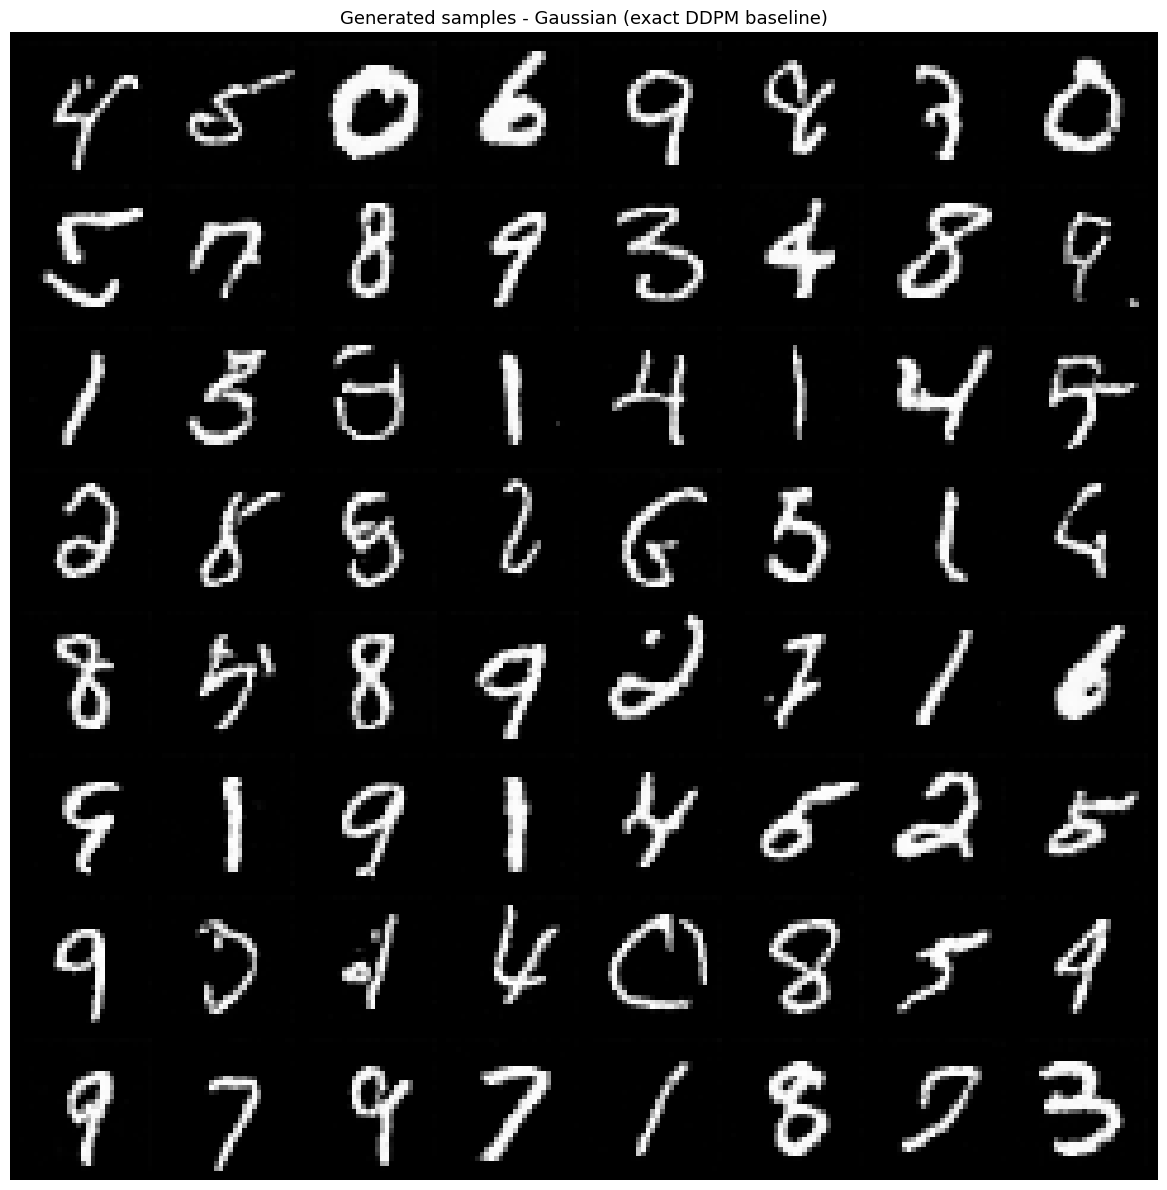

Run: Uniform (matched-variance surrogate)
Epsilon prediction under a matched-variance direct-corruption surrogate.
Starting fresh.


Epoch 1/30 [uniform]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch   1 | avg loss: 0.06851 | elapsed: 0.8 min


Epoch 2/30 [uniform]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch   2 | avg loss: 0.03027 | elapsed: 1.5 min


...

Epoch 29/30 [uniform]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  29 | avg loss: 0.01877 | elapsed: 21.8 min


Epoch 30/30 [uniform]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  30 | avg loss: 0.01862 | elapsed: 22.5 min
  Checkpoint saved: /content/drive/MyDrive/diffusion_noise_project/checkpoints/uniform/epoch_030.pt

Generating final sample grid...
Reverse sampling still uses the standard Gaussian DDPM update. That update is exact for the Gaussian baseline and should be interpreted with caution for the surrogate runs.


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

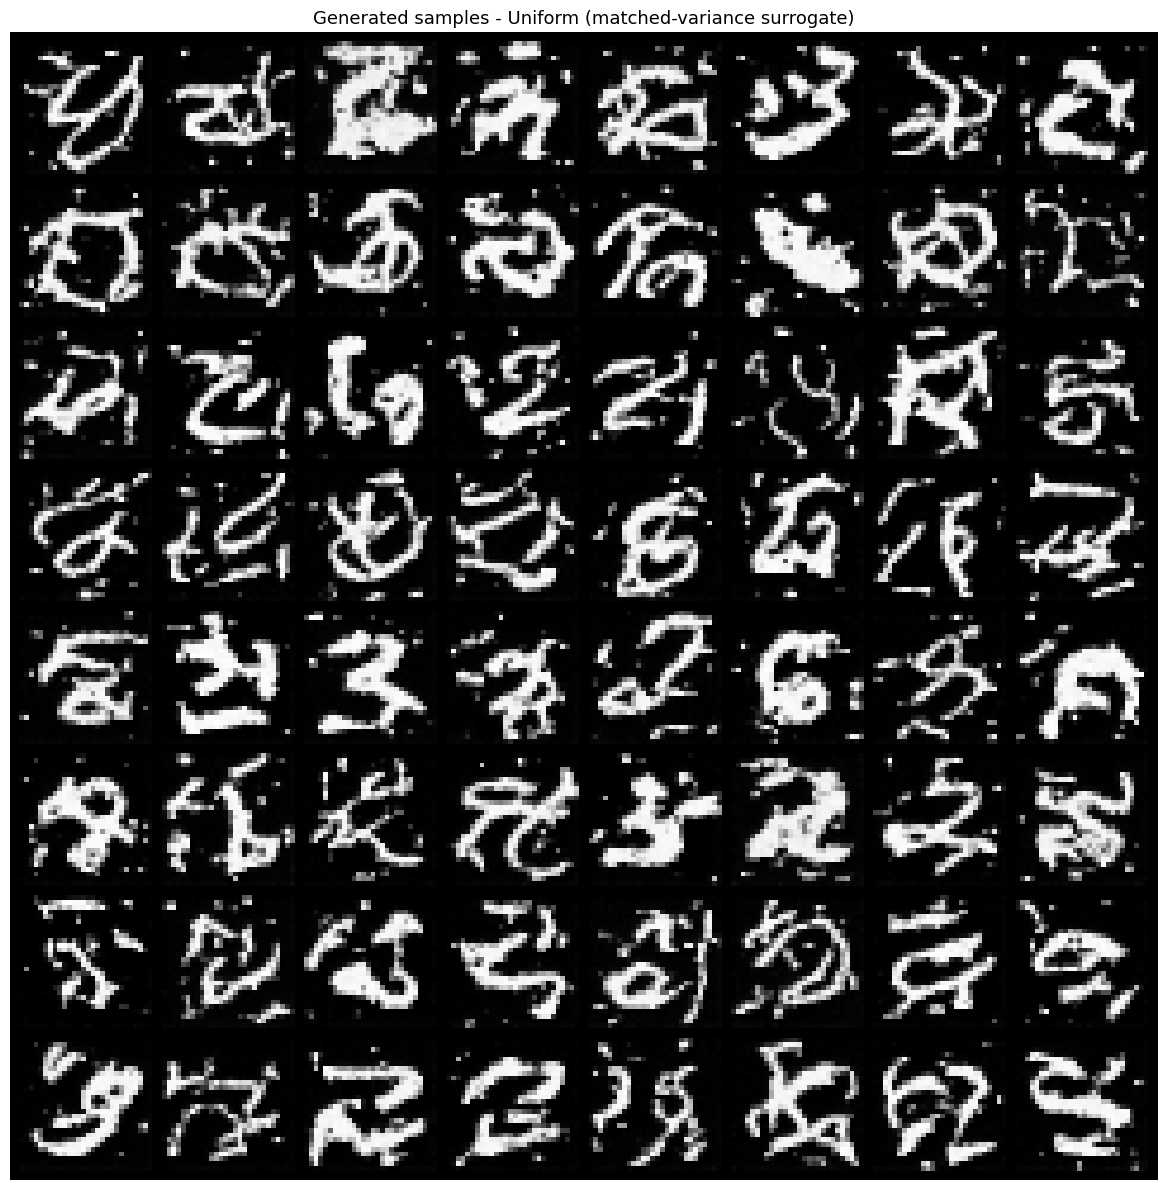

Run: Laplace (matched-variance surrogate)
Epsilon prediction under a matched-variance direct-corruption surrogate.
Starting fresh.


Epoch 1/30 [laplace]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch   1 | avg loss: 0.07008 | elapsed: 0.8 min


Epoch 2/30 [laplace]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch   2 | avg loss: 0.03098 | elapsed: 1.5 min


...

Epoch 29/30 [laplace]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  29 | avg loss: 0.02048 | elapsed: 21.8 min


Epoch 30/30 [laplace]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  30 | avg loss: 0.02045 | elapsed: 22.5 min
  Checkpoint saved: /content/drive/MyDrive/diffusion_noise_project/checkpoints/laplace/epoch_030.pt

Generating final sample grid...
Reverse sampling still uses the standard Gaussian DDPM update. That update is exact for the Gaussian baseline and should be interpreted with caution for the surrogate runs.


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

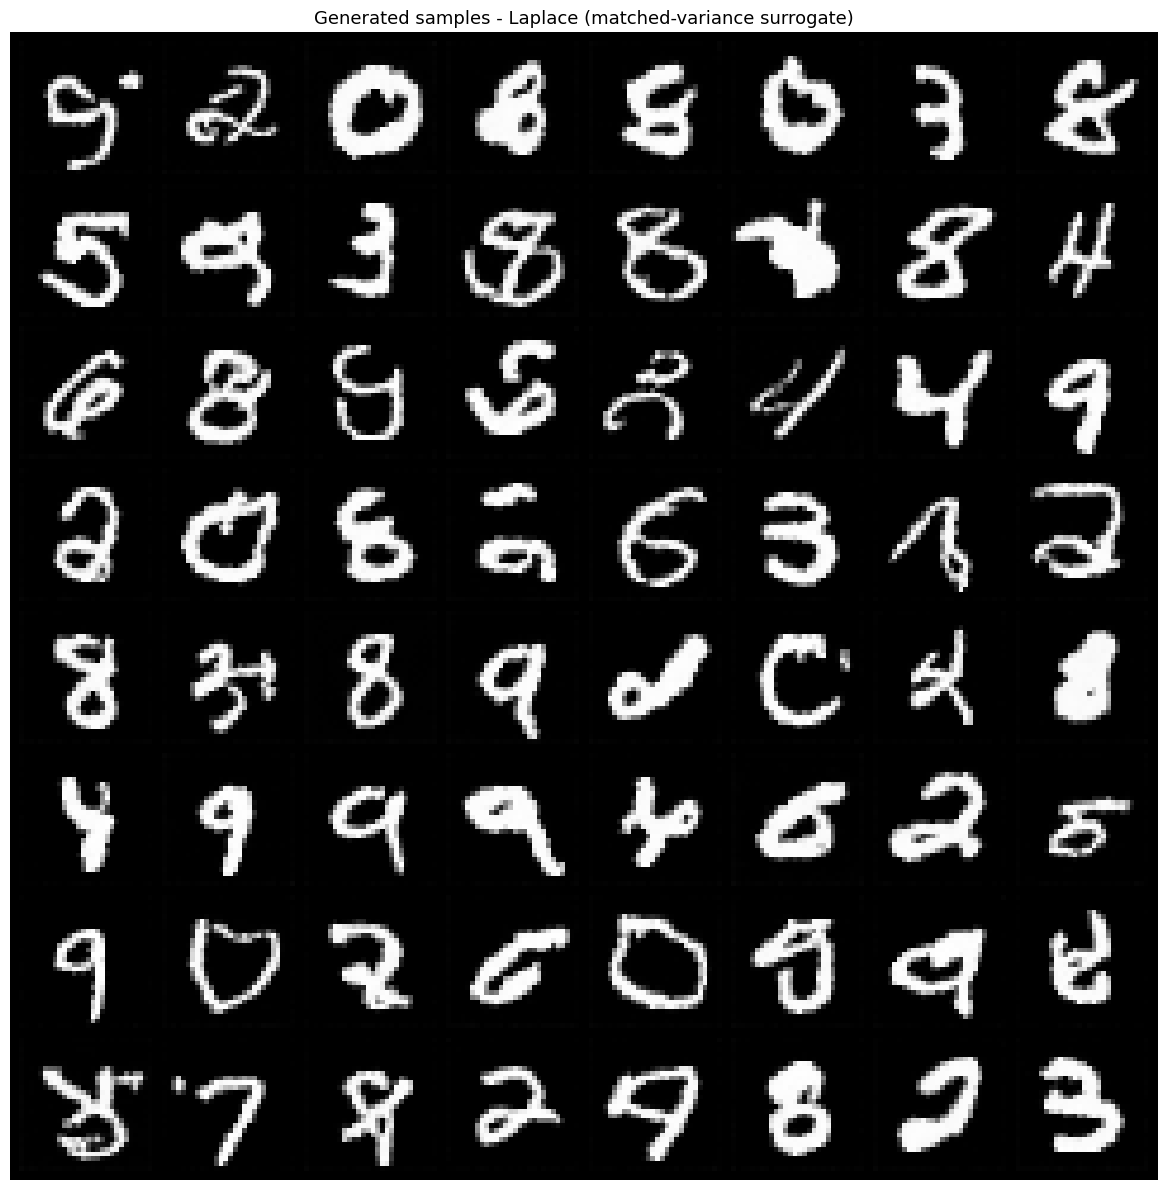

Three-run campaign complete.
Campaign summary saved to /content/drive/MyDrive/diffusion_noise_project/logs/training_campaign_summary.json


In [16]:
campaign_results = {}

for noise_type in NOISE_TYPES:
    campaign_results[noise_type] = train_one_run(noise_type)

campaign_summary = {
    'noise_types': NOISE_TYPES,
    'experimental_controls': CONTROL_SUMMARY,
    'config': CONFIG,
    'results': {},
}
for noise_type, result in campaign_results.items():
    campaign_summary['results'][noise_type] = {
        'run_label': result['run_label'],
        'training_objective': result['training_objective'],
        'final_epoch_avg_loss': result['final_epoch_avg_loss'],
        'duration_minutes': result['duration_minutes'],
        'peak_memory_gb': result['peak_memory_gb'],
        'checkpoint_directory': result['ckpt_dir'],
        'loss_log_path': result['log_path'],
        'tensorboard_dir': result['tb_dir'],
        'sample_path': result['sample_path'],
        'run_info_path': result['run_info_path'],
    }
with open(CAMPAIGN_SUMMARY_PATH, 'w') as f:
    json.dump(campaign_summary, f, indent=2)
print('Three-run campaign complete.')
print(f'Campaign summary saved to {CAMPAIGN_SUMMARY_PATH}')



## 8. Campaign Loss Overview

The figures below combine the three runs so the training notebook itself already exposes the cross-noise comparison.



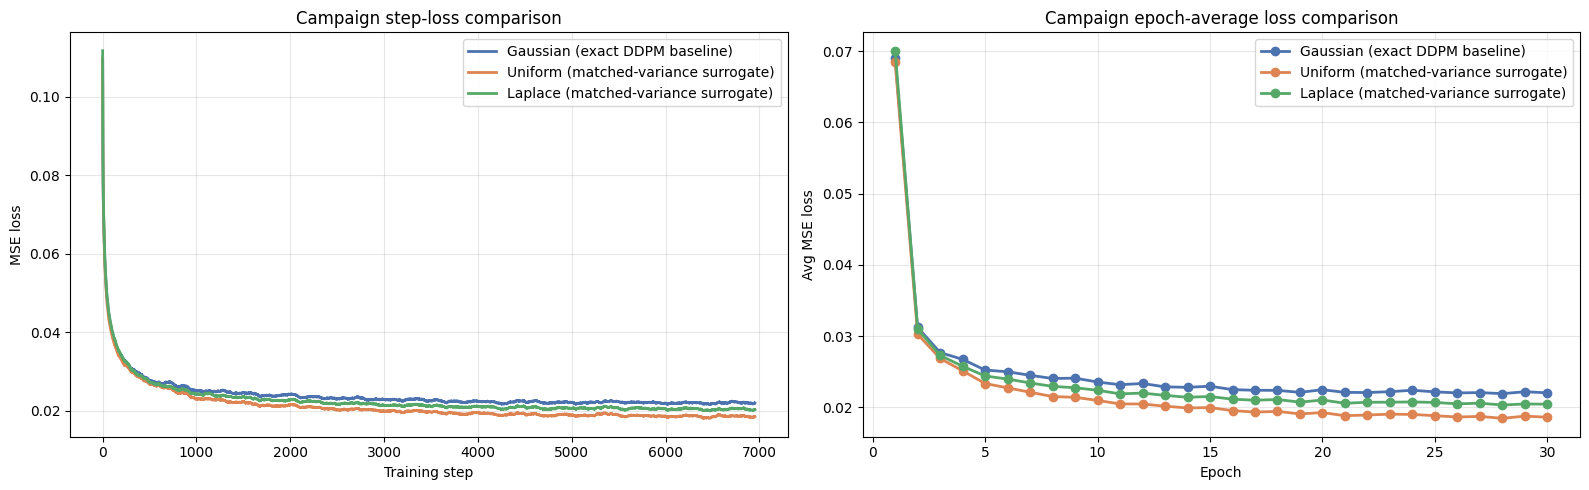

Combined campaign loss figure saved to /content/drive/MyDrive/diffusion_noise_project/figures/campaign_loss_overview.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
color_map = {'gaussian': '#4C72B0', 'uniform': '#DD8452', 'laplace': '#55A868'}

for noise_type in NOISE_TYPES:
    result = campaign_results.get(noise_type)
    if not result:
        continue
    all_losses = result['all_losses']
    epoch_losses = result['epoch_losses']
    color = color_map[noise_type]
    if all_losses:
        steps, losses = zip(*all_losses)
        window = min(100, max(10, len(losses) // 20))
        if len(losses) >= window:
            smoothed = np.convolve(losses, np.ones(window) / window, mode='valid')
            axes[0].plot(steps[:len(smoothed)], smoothed, color=color, linewidth=2, label=result['run_label'])
        else:
            axes[0].plot(steps, losses, color=color, linewidth=2, label=result['run_label'])
    if epoch_losses:
        axes[1].plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color=color, linewidth=2, label=result['run_label'])

axes[0].set_title('Campaign step-loss comparison')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('MSE loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Campaign epoch-average loss comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg MSE loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
campaign_loss_path = os.path.join(PROJECT_DIR, 'figures', 'campaign_loss_overview.png')
plt.savefig(campaign_loss_path, dpi=150)
plt.show()
print(f'Combined campaign loss figure saved to {campaign_loss_path}')



## 9. Sample Comparison

Each row corresponds to one trained run under the shared Gaussian reverse sampler used in this project.



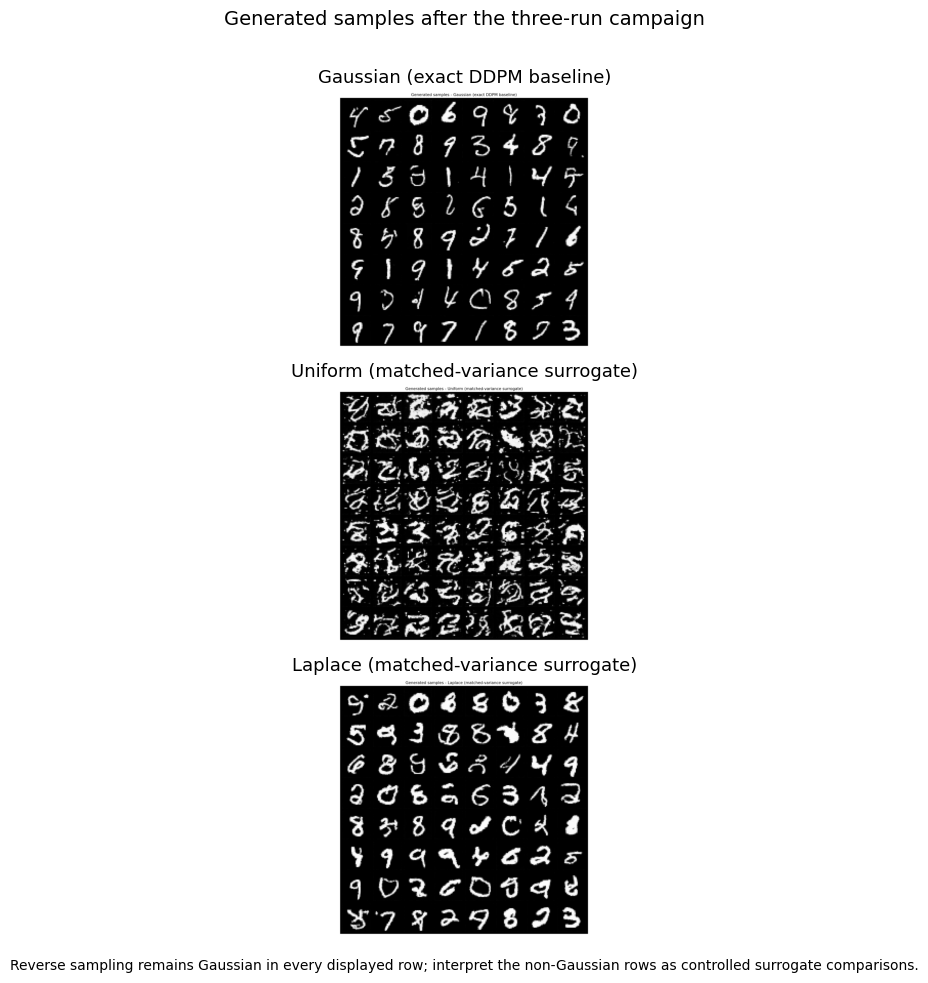

Combined campaign sample figure saved to /content/drive/MyDrive/diffusion_noise_project/figures/campaign_samples.png


In [18]:
fig, axes = plt.subplots(len(NOISE_TYPES), 1, figsize=(16, len(NOISE_TYPES) * 3.2))
if len(NOISE_TYPES) == 1:
    axes = [axes]

for ax, noise_type in zip(axes, NOISE_TYPES):
    image = plt.imread(campaign_results[noise_type]['sample_path'])
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(campaign_results[noise_type]['run_label'], fontsize=13)

plt.suptitle('Generated samples after the three-run campaign', fontsize=14, y=1.01)
plt.figtext(
    0.5,
    0.01,
    'Reverse sampling remains Gaussian in every displayed row; interpret the non-Gaussian rows as controlled surrogate comparisons.',
    ha='center',
    fontsize=10,
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
campaign_sample_path = os.path.join(PROJECT_DIR, 'figures', 'campaign_samples.png')
plt.savefig(campaign_sample_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Combined campaign sample figure saved to {campaign_sample_path}')



In [19]:
print('Notebook 4 complete. The full three-run training campaign has been executed sequentially.')
print()

for noise_type in NOISE_TYPES:
    result = campaign_results[noise_type]
    print(result['run_label'])
    if result['final_epoch_avg_loss'] is not None:
        print(f'  Final epoch-average loss: {result["final_epoch_avg_loss"]:.5f}')
    if result['duration_minutes'] is not None:
        print(f'  Duration: {result["duration_minutes"]:.1f} min')
    if result['peak_memory_gb'] is not None:
        print(f'  Peak GPU memory: {result["peak_memory_gb"]:.2f} GB')
    print(f'  Checkpoints:  {result["ckpt_dir"]}/')
    print(f'  Loss log:     {result["log_path"]}')
    print(f'  Samples:      {result["sample_path"]}')
    print(f'  TensorBoard:  {result["tb_dir"]}')
    print(f'  Run metadata: {result["run_info_path"]}')
    print()

print('Campaign-level files:')
print(f'  {CAMPAIGN_SUMMARY_PATH}')
print(f'  {os.path.join(PROJECT_DIR, "figures", "campaign_loss_overview.png")}')
print(f'  {os.path.join(PROJECT_DIR, "figures", "campaign_samples.png")}')
print()
print('TensorBoard in Colab:')
print('%load_ext tensorboard')
print(f'%tensorboard --logdir {os.path.join(PROJECT_DIR, "tensorboard")}')
print('Proceed to Notebook 5 for the three-way evaluation and comparison.')



Notebook 4 complete. The full three-run training campaign has been executed sequentially.

Gaussian (exact DDPM baseline)
  Final epoch-average loss: 0.02204
  Duration: 23.1 min
  Peak GPU memory: 2.28 GB
  Checkpoints:  /content/drive/MyDrive/diffusion_noise_project/checkpoints/gaussian/
  Loss log:     /content/drive/MyDrive/diffusion_noise_project/logs/gaussian_loss.csv
  Samples:      /content/drive/MyDrive/diffusion_noise_project/samples/gaussian_final.png
  TensorBoard:  /content/drive/MyDrive/diffusion_noise_project/tensorboard/gaussian
  Run metadata: /content/drive/MyDrive/diffusion_noise_project/logs/gaussian_run_info.json

Uniform (matched-variance surrogate)
  Final epoch-average loss: 0.01862
  Duration: 22.5 min
  Peak GPU memory: 2.16 GB
  Checkpoints:  /content/drive/MyDrive/diffusion_noise_project/checkpoints/uniform/
  Loss log:     /content/drive/MyDrive/diffusion_noise_project/logs/uniform_loss.csv
  Samples:      /content/drive/MyDrive/diffusion_noise_project/samp